# **AI-Based Battery State Estimation Algorithm Research**

**Project Overview:**

This notebook implements various machine learning algorithms for battery State of Health (SoH) estimation using the NASA Battery Aging Dataset. The research focuses on developing robust estimation algorithms through advanced feature engineering and comparative analysis of multiple ML approaches.

---

### **1. Package Loading and Environment Setup**

#### **1.1 Import Core Libraries**

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Data manipulation and analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# File handling and utilities
import os
import glob
from pathlib import Path

### **2. Data Loading and Initial Inspectiion**

#### **2.1 Dataset Path Configuration**

In [2]:
# Define data paths
BASE_PATH = "cleaned_dataset"
METADATA_PATH = os.path.join(BASE_PATH, "metadata.csv")
DATA_FOLDER = os.path.join(BASE_PATH, "data")

# Verify paths exist
if not os.path.exists(METADATA_PATH):
    raise FileNotFoundError(f"Metadata file not found at: {METADATA_PATH}")
if not os.path.exists(DATA_FOLDER):
    raise FileNotFoundError(f"Data folder not found at: {DATA_FOLDER}")

print(f"Base path: {BASE_PATH}")
print(f"Metadata path: {METADATA_PATH}")
print(f"Data folder: {DATA_FOLDER}")

Base path: cleaned_dataset
Metadata path: cleaned_dataset/metadata.csv
Data folder: cleaned_dataset/data


#### **2.2 Metadata Loading and Inspection**

In [3]:
# Load metadata
metadata = pd.read_csv(METADATA_PATH)

print("Metadata Dataset Information (Before Type Conversion):")
print("=" * 50)
print(f"Dataset shape: {metadata.shape}")
print(f"Memory usage: {metadata.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nColumn information:")
print(metadata.dtypes)
print("\n" + "=" * 50)

# Display first few rows of metadata
print("First few rows of metadata:")
display(metadata.head())

Metadata Dataset Information (Before Type Conversion):
Dataset shape: (7565, 10)
Memory usage: 3.35 MB

Column information:
type                   object
start_time             object
ambient_temperature     int64
battery_id             object
test_id                 int64
uid                     int64
filename               object
Capacity               object
Re                     object
Rct                    object
dtype: object

First few rows of metadata:


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


#### **2.3 Data Type Conversion and Metadata Preprocessing**

In [4]:
# Convert numerical columns from object to appropriate types
def preprocess_metadata(df):
    """
    Preprocess metadata by converting data types and handling missing values
    """
    df = df.copy()
    
    # Convert Capacity, Re, Rct to numeric (they are stored as strings)
    numeric_columns = ['Capacity', 'Re', 'Rct']
    for col in numeric_columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df

# Apply preprocessing
metadata = preprocess_metadata(metadata)

print("Metadata Dataset Information (After Type Conversion):")
print("=" * 50)
print(f"Dataset shape: {metadata.shape}")
print(f"Memory usage: {metadata.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nColumn information:")
print(metadata.dtypes)
print("\nMissing values:")
print(metadata.isnull().sum())

Metadata Dataset Information (After Type Conversion):
Dataset shape: (7565, 10)
Memory usage: 2.55 MB

Column information:
type                    object
start_time              object
ambient_temperature      int64
battery_id              object
test_id                  int64
uid                      int64
filename                object
Capacity               float64
Re                     float64
Rct                    float64
dtype: object

Missing values:
type                      0
start_time                0
ambient_temperature       0
battery_id                0
test_id                   0
uid                       0
filename                  0
Capacity               4796
Re                     5618
Rct                    5618
dtype: int64


#### **2.4 Battery Identification and Data Overview**

In [5]:
# Identify unique batteries in the dataset
unique_batteries = metadata['battery_id'].unique()
print(f"Available batteries: {sorted(unique_batteries)}")
print(f"Total number of batteries: {len(unique_batteries)}")

# Analyze test types distribution
test_type_counts = metadata['type'].value_counts()
print(f"\nTest type distribution:")
print(test_type_counts)

# Battery-wise data distribution
battery_distribution = metadata.groupby('battery_id').agg({
    'type': 'count',
    'Capacity': lambda x: x.notna().sum(),
    'Re': lambda x: x.notna().sum(),
    'Rct': lambda x: x.notna().sum()
}).rename(columns={'type': 'total_cycles'})

print(f"\nBattery-wise data distribution:")
display(battery_distribution)

Available batteries: ['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028', 'B0029', 'B0030', 'B0031', 'B0032', 'B0033', 'B0034', 'B0036', 'B0038', 'B0039', 'B0040', 'B0041', 'B0042', 'B0043', 'B0044', 'B0045', 'B0046', 'B0047', 'B0048', 'B0049', 'B0050', 'B0051', 'B0052', 'B0053', 'B0054', 'B0055', 'B0056']
Total number of batteries: 34

Test type distribution:
type
charge       2815
discharge    2794
impedance    1956
Name: count, dtype: int64

Battery-wise data distribution:


,total_cycles,Capacity,Re,Rct
battery_id,,,,
B0005,616,168,278,278
B0006,616,168,278,278
B0007,616,168,278,278
B0018,319,132,53,53
B0025,80,28,21,21
B0026,80,28,21,21
B0027,80,28,21,21
B0028,80,28,21,21
B0029,97,40,17,17


#### **2.5 Sample Cycle Data Loading and Inspection**

In [6]:
# Load a sample cycle file to understand the structure
sample_file = os.path.join(DATA_FOLDER, "00001.csv")

if os.path.exists(sample_file):
    sample_cycle = pd.read_csv(sample_file)
    
    print("Sample Cycle Data Information:")
    print("=" * 40)
    print(f"Dataset shape: {sample_cycle.shape}")
    print(f"Memory usage: {sample_cycle.memory_usage(deep=True).sum() / 1024:.2f} KB")
    print("\nColumn information:")
    print(sample_cycle.dtypes)
    
    print(f"\nFirst few rows of sample cycle data:")
    display(sample_cycle.head())
    
    print(f"\nBasic statistics:")
    display(sample_cycle.describe())
else:
    print(f"Sample file {sample_file} not found")

Sample Cycle Data Information:
Dataset shape: (490, 6)
Memory usage: 23.10 KB

Column information:
Voltage_measured        float64
Current_measured        float64
Temperature_measured    float64
Current_load            float64
Voltage_load            float64
Time                    float64
dtype: object

First few rows of sample cycle data:


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,4.246711,0.000252,6.212696,0.0002,0.000,0.000
1,4.246764,-0.001411,6.234019,0.0002,4.262,9.360
2,4.039277,-0.995093,6.250255,1.0000,3.465,23.281
3,4.019506,-0.996731,6.302176,1.0000,3.451,36.406
4,4.004763,-0.992845,6.361645,1.0000,3.438,49.625



Basic statistics:


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
count,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000
mean,3.475266,-0.952767,8.272423,0.957153,2.817939,3205.134141
std,0.284626,0.201448,1.455269,0.202690,0.644985,1861.395346
min,2.470612,-1.001101,5.008084,0.000200,0.000000,0.000000
25%,3.336993,-0.995898,7.313213,1.000000,2.790500,1598.417750
50%,3.491946,-0.995207,8.184590,1.000000,2.945500,3200.492500
75%,3.655987,-0.994648,9.025544,1.000000,3.105750,4809.176250
max,4.246764,0.000252,12.376816,1.000000,4.262000,6436.141000


### **3. Cycle Data Processing and Capacity Calculation**

#### **3.1 Import Additional Libraries for Cycle Processing**

In [7]:
# Additional imports for this section
from scipy import integrate
from scipy.signal import find_peaks
import concurrent.futures
from typing import Dict, List, Tuple, Optional

#### **3.2 Cycle Data Loading Functions**

In [13]:
def load_cycle_data(filename: str) -> pd.DataFrame:
    """
    Load individual cycle data from CSV file
    """
    filepath = os.path.join(DATA_FOLDER, filename)
    if os.path.exists(filepath):
        return pd.read_csv(filepath)
    else:
        return None
    
def calculate_capacity_coulomb_counting(cycle_df: pd.DataFrame) -> float:
    """
    Calculate capacity using Coulomb counting method
    Capacity = ∫|Current| dt (in Ah)
    """
    if cycle_df is None or len(cycle_df) < 2:
        return np.nan
    
    # Sort by time to ensure proper integration
    cycle_df = cycle_df.sort_values('Time').reset_index(drop=True)
    
    # Calculate capacity using trapezoidal integration
    # Convert current to absolute value (discharge current is negative)
    current_abs = np.abs(cycle_df['Current_measured'].values)
    time_hours = cycle_df['Time'].values / 3600  # Convert seconds to hours
    
    # Integrate using trapezoidal rule
    capacity_ah = np.trapz(current_abs, time_hours)
    
    return capacity_ah

def extract_cycle_features(cycle_df: pd.DataFrame) -> Dict[str, float]:
    """
    Extract key features from a single cycle
    """
    if cycle_df is None or len(cycle_df) == 0:
        return {}
    
    features = {}

    # Basic statistics
    features['voltage_start'] = cycle_df['Voltage_measured'].iloc[0]
    features['voltage_end'] = cycle_df['Voltage_measured'].iloc[-1]
    features['voltage_mean'] = cycle_df['Voltage_measured'].mean()
    features['voltage_min'] = cycle_df['Voltage_measured'].min()
    features['voltage_drop'] = features['voltage_start'] - features['voltage_end']
    
    # Current features
    features['current_mean'] = cycle_df['Current_measured'].mean()
    features['current_std'] = cycle_df['Current_measured'].std()
    
    # Temperature features
    features['temperature_mean'] = cycle_df['Temperature_measured'].mean()
    features['temperature_max'] = cycle_df['Temperature_measured'].max()
    features['temperature_range'] = (cycle_df['Temperature_measured'].max() - 
                                     cycle_df['Temperature_measured'].min())
    
    # Time features
    features['duration_seconds'] = cycle_df['Time'].max()
    features['duration_hours'] = features['duration_seconds'] / 3600
    
    # Energy delivered (Wh)
    if len(cycle_df) > 1:
        power = np.abs(cycle_df['Voltage_measured'] * cycle_df['Current_measured'])
        time_hours = cycle_df['Time'] / 3600
        features['energy_wh'] = np.trapz(power, time_hours)
    else:
        features['energy_wh'] = 0
    
    return features

#### **3.3 Process Sample Cycles and Validate Capacity Calculation**

In [14]:
# Test on a few discharge cycles with known capacity
test_cycles = metadata[
    (metadata['type'] == 'discharge') & 
    (metadata['Capacity'].notna())
].head(10)

print("Validating capacity calculation on sample discharge cycles:")
print("=" * 70)

validation_results = []

for idx, row in test_cycles.iterrows():
    cycle_data = load_cycle_data(row['filename'])
    
    if cycle_data is not None:
        # Calculate capacity
        calculated_capacity = calculate_capacity_coulomb_counting(cycle_data)
        metadata_capacity = row['Capacity']
        
        # Calculate error
        error = abs(calculated_capacity - metadata_capacity)
        percent_error = (error / metadata_capacity) * 100 if metadata_capacity > 0 else np.nan
        
        validation_results.append({
            'filename': row['filename'],
            'battery_id': row['battery_id'],
            'metadata_capacity': metadata_capacity,
            'calculated_capacity': calculated_capacity,
            'absolute_error': error,
            'percent_error': percent_error
        })

validation_df = pd.DataFrame(validation_results)
print(f"\nValidation Results:")
print(validation_df.to_string(index=False))
print(f"\nMean Absolute Error: {validation_df['absolute_error'].mean():.4f} Ah")
print(f"Mean Percent Error: {validation_df['percent_error'].mean():.2f}%")

Validating capacity calculation on sample discharge cycles:

Validation Results:
 filename battery_id  metadata_capacity  calculated_capacity  absolute_error  percent_error
00001.csv      B0047           1.674305             1.705934        0.031629       1.889098
00005.csv      B0047           1.524366             1.548536        0.024169       1.585544
00007.csv      B0047           1.508076             1.532319        0.024242       1.607504
00009.csv      B0047           1.483558             1.511623        0.028065       1.891751
00011.csv      B0047           1.467139             1.495241        0.028102       1.915411
00013.csv      B0047           1.448858             1.477025        0.028167       1.944062
00017.csv      B0047           1.445853             1.474083        0.028229       1.952433
00021.csv      B0047           1.431118             1.463152        0.032034       2.238397
00023.csv      B0047           1.419275             1.443801        0.024526       1.728078

#### **3.4 Extract Features for Sample Cycles**

In [15]:
# Extract features for the same sample cycles
print("\nExtracting features from sample cycles:")
print("=" * 50)

sample_features = []

for idx, row in test_cycles.head(3).iterrows():
    cycle_data = load_cycle_data(row['filename'])
    
    if cycle_data is not None:
        features = extract_cycle_features(cycle_data)
        features['filename'] = row['filename']
        features['battery_id'] = row['battery_id']
        features['calculated_capacity'] = calculate_capacity_coulomb_counting(cycle_data)
        sample_features.append(features)

# Display sample features
features_df = pd.DataFrame(sample_features)
print("\nSample extracted features:")
for col in features_df.columns:
    if col not in ['filename', 'battery_id']:
        print(f"{col}: {features_df[col].values}")


Extracting features from sample cycles:

Sample extracted features:
voltage_start: [4.24671125 4.18663571 4.19992275]
voltage_end: [3.32935648 3.12815663 3.12737934]
voltage_mean: [3.47526648 3.47655882 3.47076696]
voltage_min: [2.47061187 2.47766165 2.47070987]
voltage_drop: [0.91735477 1.05847908 1.07254342]
current_mean: [-0.95276684 -0.9838885  -0.98388926]
current_std: [0.20144764 0.10670769 0.1073148 ]
temperature_mean: [8.27242252 8.21071542 7.95445506]
temperature_max: [12.37681588 11.31490332 11.62452819]
temperature_range: [7.36873159 5.8599466  6.70235007]
duration_seconds: [6436.141 5650.265 5590.907]
duration_hours: [1.78781694 1.56951806 1.55302972]
energy_wh: [5.938077   5.38101104 5.31560564]
calculated_capacity: [1.70593401 1.5485357  1.53231869]


#### **3.5 Process All Discharge Cycles**

In [20]:
def calculate_capacity_with_voltage_threshold(cycle_df: pd.DataFrame, 
                                             voltage_threshold: float = 2.7) -> float:
    """
    Calculate capacity using Coulomb counting with voltage threshold
    Stops integration when voltage drops below threshold
    """
    if cycle_df is None or len(cycle_df) < 2:
        return np.nan
    
    # Sort by time
    cycle_df = cycle_df.sort_values('Time').reset_index(drop=True)
    
    # Find where voltage drops below threshold
    below_threshold = cycle_df['Voltage_measured'] < voltage_threshold
    
    if below_threshold.any():
        # Get index of first occurrence below threshold
        cutoff_idx = below_threshold.idxmax()
        # Use data only up to threshold
        cycle_df = cycle_df.iloc[:cutoff_idx + 1]
    
    if len(cycle_df) < 2:
        return np.nan
    
    # Calculate capacity
    current_abs = np.abs(cycle_df['Current_measured'].values)
    time_hours = cycle_df['Time'].values / 3600
    
    capacity_ah = np.trapz(current_abs, time_hours)
    
    return capacity_ah

def process_discharge_cycles_refined(metadata_df: pd.DataFrame,
                                   exclude_batteries: List[str] = ['B0049', 'B0050', 'B0051', 'B0052'],
                                   voltage_threshold: float = 2.7,
                                   capacity_bounds: Tuple[float, float] = (0.5, 2.5)) -> pd.DataFrame:
    """
    Process discharge cycles with refined filtering and validation
    """
    # Filter discharge cycles and exclude problematic batteries
    discharge_cycles = metadata_df[
        (metadata_df['type'] == 'discharge') & 
        (~metadata_df['battery_id'].isin(exclude_batteries))
    ].copy()
    
    print(f"Total discharge cycles to process (excluding {exclude_batteries}): {len(discharge_cycles)}")
    print("=" * 70)
    
    all_features = []
    anomaly_count = 0
    
    for idx, row in tqdm(discharge_cycles.iterrows(), total=len(discharge_cycles), desc="Processing cycles"):
        cycle_data = load_cycle_data(row['filename'])
        
        if cycle_data is not None and len(cycle_data) > 10:  # Minimum data points
            # Calculate capacity with voltage threshold
            calculated_capacity = calculate_capacity_with_voltage_threshold(cycle_data, voltage_threshold)
            
            # Check if capacity is within reasonable bounds
            if capacity_bounds[0] <= calculated_capacity <= capacity_bounds[1]:
                # Extract features
                features = extract_cycle_features(cycle_data)
                features['calculated_capacity'] = calculated_capacity
                
                # Add metadata
                features['filename'] = row['filename']
                features['battery_id'] = row['battery_id']
                features['test_id'] = row['test_id']
                features['uid'] = row['uid']
                features['ambient_temperature'] = row['ambient_temperature']
                features['metadata_capacity'] = row['Capacity']
                
                # Additional features for voltage profile
                features['time_to_2_7v'] = (cycle_data[cycle_data['Voltage_measured'] < voltage_threshold]['Time'].min() 
                                           if any(cycle_data['Voltage_measured'] < voltage_threshold) else cycle_data['Time'].max())
                
                all_features.append(features)
            else:
                anomaly_count += 1
    
    features_df = pd.DataFrame(all_features)
    
    # Add cycle number for each battery
    features_df['cycle_number'] = features_df.groupby('battery_id').cumcount() + 1
    
    print(f"\nProcessed {len(features_df)} discharge cycles successfully")
    print(f"Excluded {anomaly_count} cycles with anomalous capacity values")
    
    return features_df

# Reprocess with refined method
discharge_features_refined = process_discharge_cycles_refined(metadata)

Total discharge cycles to process (excluding ['B0049', 'B0050', 'B0051', 'B0052']): 2694


Processing cycles: 100%|██████████| 2694/2694 [00:02<00:00, 1132.61it/s]


Processed 2490 discharge cycles successfully
Excluded 178 cycles with anomalous capacity values


#### **3.6 Analyze Processed Data**

In [21]:
print("\nRefined Processing Results:")
print("=" * 50)
print(f"Total valid discharge cycles: {len(discharge_features_refined)}")
print(f"Number of batteries: {discharge_features_refined['battery_id'].nunique()}")
print(f"\nCapacity statistics (refined):")
print(f"Mean capacity: {discharge_features_refined['calculated_capacity'].mean():.3f} Ah")
print(f"Std capacity: {discharge_features_refined['calculated_capacity'].std():.3f} Ah")
print(f"Min capacity: {discharge_features_refined['calculated_capacity'].min():.3f} Ah")
print(f"Max capacity: {discharge_features_refined['calculated_capacity'].max():.3f} Ah")

# Check excluded batteries are not present
excluded_batteries = ['B0049', 'B0050', 'B0051', 'B0052']
batteries_in_data = discharge_features_refined['battery_id'].unique()
print(f"\nExcluded batteries check:")
for bat in excluded_batteries:
    print(f"{bat}: {'NOT in data ✓' if bat not in batteries_in_data else 'Still in data ✗'}")


Refined Processing Results:
Total valid discharge cycles: 2490
Number of batteries: 30

Capacity statistics (refined):
Mean capacity: 1.444 Ah
Std capacity: 0.299 Ah
Min capacity: 0.545 Ah
Max capacity: 2.444 Ah

Excluded batteries check:
B0049: NOT in data ✓
B0050: NOT in data ✓
B0051: NOT in data ✓
B0052: NOT in data ✓


#### **3.7 Anomaly Detection and Visualization**

In [22]:
def detect_capacity_anomalies(battery_data: pd.DataFrame, 
                             max_increase: float = 0.1,  # Max 10% increase between cycles
                             max_decrease: float = 0.3,  # Max 30% decrease between cycles
                             rolling_window: int = 5) -> pd.DataFrame:
    """
    Detect anomalies in capacity degradation
    """
    battery_data = battery_data.sort_values('cycle_number').copy()
    
    # Calculate capacity change
    battery_data['capacity_change'] = battery_data['calculated_capacity'].diff()
    battery_data['capacity_change_pct'] = battery_data['calculated_capacity'].pct_change()
    
    # Calculate rolling statistics
    battery_data['capacity_rolling_mean'] = battery_data['calculated_capacity'].rolling(
        window=rolling_window, center=True, min_periods=1).mean()
    battery_data['capacity_rolling_std'] = battery_data['calculated_capacity'].rolling(
        window=rolling_window, center=True, min_periods=1).std()
    
    # Flag anomalies
    battery_data['is_spike'] = battery_data['capacity_change_pct'] > max_increase
    battery_data['is_drop'] = battery_data['capacity_change_pct'] < -max_decrease
    battery_data['is_outlier'] = (
        np.abs(battery_data['calculated_capacity'] - battery_data['capacity_rolling_mean']) > 
        2 * battery_data['capacity_rolling_std']
    )
    
    battery_data['is_anomaly'] = (
        battery_data['is_spike'] | 
        battery_data['is_drop'] | 
        battery_data['is_outlier']
    )
    
    return battery_data

# Analyze anomalies for all batteries
anomaly_summary = []

for battery_id in discharge_features_refined['battery_id'].unique():
    battery_data = discharge_features_refined[
        discharge_features_refined['battery_id'] == battery_id
    ].copy()
    
    battery_data = detect_capacity_anomalies(battery_data)
    
    anomaly_summary.append({
        'battery_id': battery_id,
        'total_cycles': len(battery_data),
        'anomaly_count': battery_data['is_anomaly'].sum(),
        'anomaly_percentage': (battery_data['is_anomaly'].sum() / len(battery_data)) * 100,
        'spike_count': battery_data['is_spike'].sum(),
        'drop_count': battery_data['is_drop'].sum(),
        'outlier_count': battery_data['is_outlier'].sum()
    })

anomaly_df = pd.DataFrame(anomaly_summary).sort_values('anomaly_percentage', ascending=False)

print("Battery Anomaly Analysis:")
print("=" * 80)
display(anomaly_df.head(10))

Battery Anomaly Analysis:


,battery_id,total_cycles,anomaly_count,anomaly_percentage,spike_count,drop_count,outlier_count
0,B0047,72,5,6.944444,3,2,0
2,B0048,72,5,6.944444,3,2,0
3,B0046,72,5,6.944444,3,2,0
7,B0040,46,3,6.521739,2,1,0
12,B0038,47,2,4.255319,2,0,0
13,B0033,188,7,3.723404,6,1,0
20,B0026,28,1,3.571429,1,0,0
11,B0034,197,6,3.045685,6,0,0
27,B0054,102,3,2.941176,3,0,0
1,B0045,72,2,2.777778,2,0,0


#### **3.8 Visualize Anomalies in Detail**

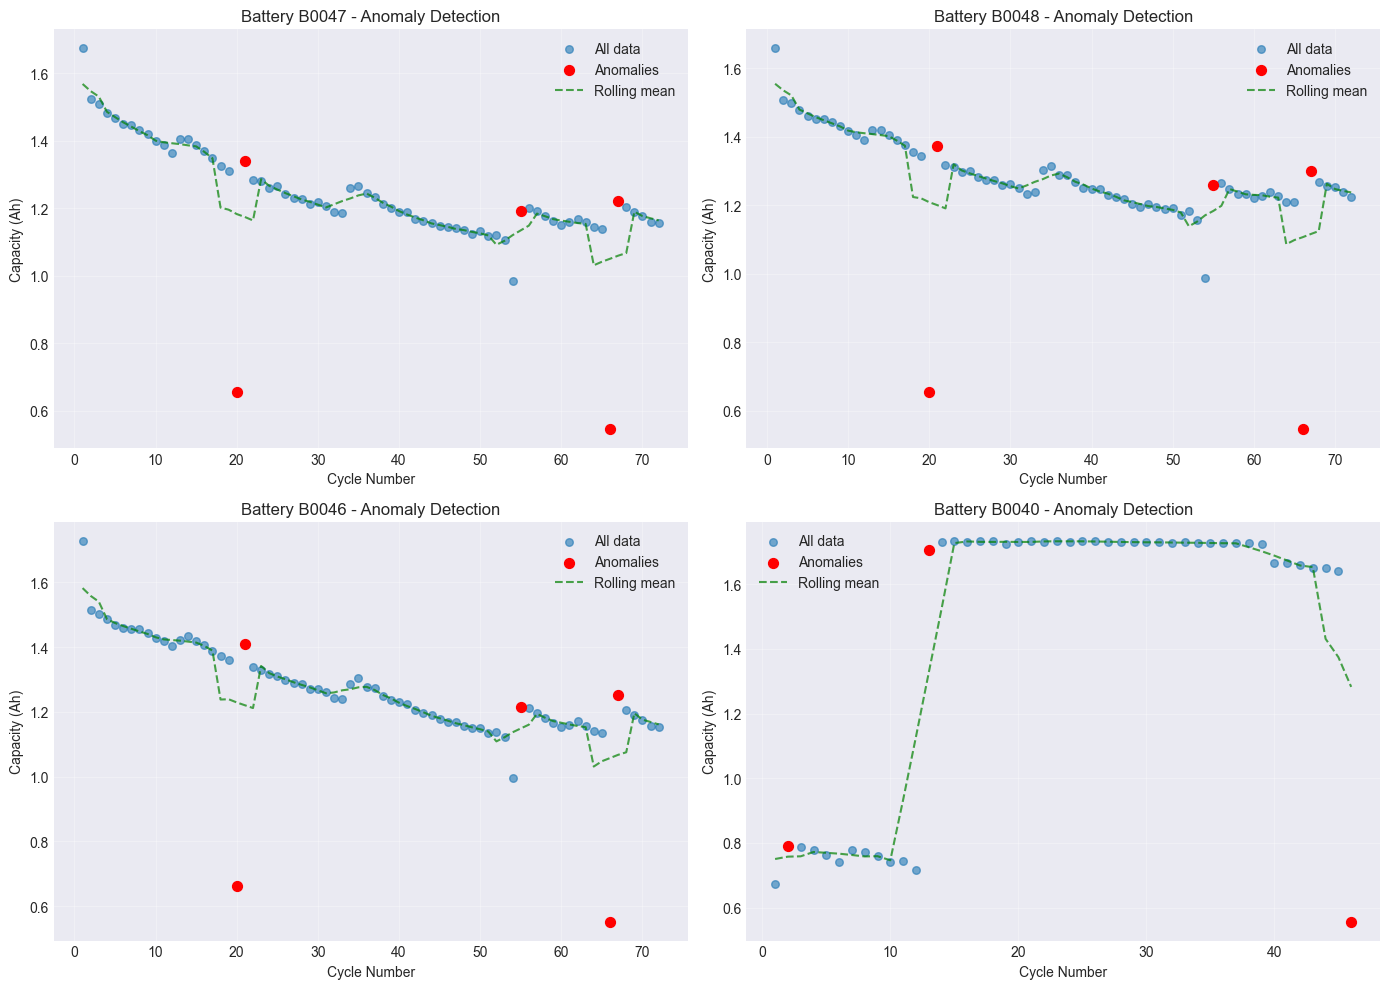

In [23]:
# Visualize anomalies for problematic batteries
problematic_batteries = anomaly_df[anomaly_df['anomaly_percentage'] > 5]['battery_id'].head(4)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, battery_id in enumerate(problematic_batteries):
    battery_data = discharge_features_refined[
        discharge_features_refined['battery_id'] == battery_id
    ].copy()
    battery_data = detect_capacity_anomalies(battery_data)
    
    ax = axes[idx]
    
    # Plot all points
    ax.scatter(battery_data['cycle_number'], 
              battery_data['calculated_capacity'], 
              alpha=0.6, s=30, label='All data')
    
    # Highlight anomalies
    anomalies = battery_data[battery_data['is_anomaly']]
    ax.scatter(anomalies['cycle_number'], 
              anomalies['calculated_capacity'], 
              color='red', s=50, label='Anomalies', zorder=5)
    
    # Plot rolling mean
    ax.plot(battery_data['cycle_number'], 
           battery_data['capacity_rolling_mean'], 
           'g--', alpha=0.7, label='Rolling mean')
    
    ax.set_xlabel('Cycle Number')
    ax.set_ylabel('Capacity (Ah)')
    ax.set_title(f'Battery {battery_id} - Anomaly Detection')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### **3.9 Apply Anomaly Filtering**

In [24]:
def filter_anomalous_cycles(features_df: pd.DataFrame,
                          max_increase: float = 0.1,
                          max_decrease: float = 0.3) -> pd.DataFrame:
    """
    Filter out anomalous cycles from the dataset
    """
    filtered_data = []
    
    for battery_id in features_df['battery_id'].unique():
        battery_data = features_df[features_df['battery_id'] == battery_id].copy()
        battery_data = battery_data.sort_values('cycle_number')
        
        # Detect anomalies
        battery_data = detect_capacity_anomalies(battery_data, max_increase, max_decrease)
        
        # Keep only non-anomalous data
        clean_data = battery_data[~battery_data['is_anomaly']]
        
        # Recalculate cycle numbers after filtering
        clean_data = clean_data.copy()
        clean_data['cycle_number'] = range(1, len(clean_data) + 1)
        
        filtered_data.append(clean_data)
    
    return pd.concat(filtered_data, ignore_index=True)

# Apply filtering
discharge_features_clean = filter_anomalous_cycles(discharge_features_refined)

print(f"Original cycles: {len(discharge_features_refined)}")
print(f"Clean cycles: {len(discharge_features_clean)}")
print(f"Removed: {len(discharge_features_refined) - len(discharge_features_clean)} anomalous cycles")

Original cycles: 2490
Clean cycles: 2437
Removed: 53 anomalous cycles


### **4. Voltage Profile Extraction and Interpolation**

#### **4.1 Import Additional Libraries for Deep Learning Preparation**

In [25]:
from scipy.interpolate import interp1d
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pickle

#### **4.2 Extract Full Voltage Profiles with Interpolation**

Sample interpolated profile:
Voltage shape: (100,)
Current shape: (100,)
Temperature shape: (100,)
Discharge duration: 6071.91 seconds


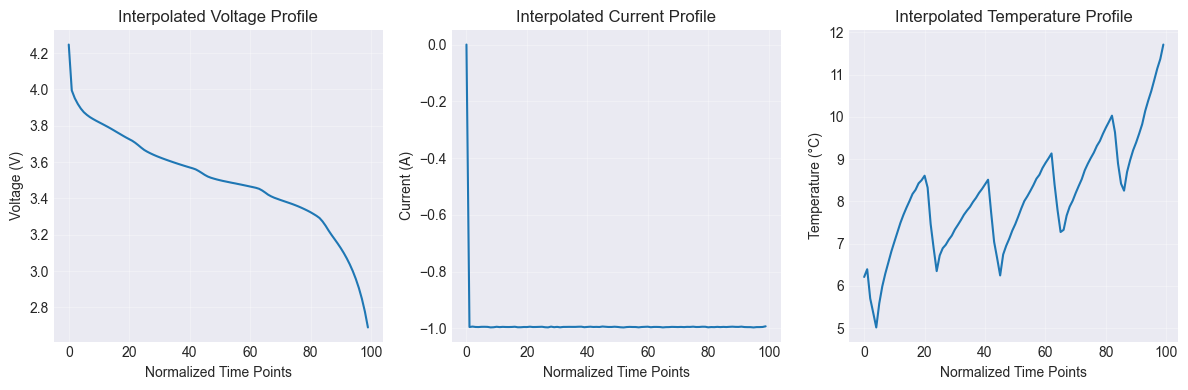

In [26]:
def interpolate_discharge_profile(cycle_df: pd.DataFrame, 
                                 n_points: int = 100,
                                 voltage_threshold: float = 2.7) -> Dict[str, np.ndarray]:
    """
    Interpolate discharge profile to fixed number of points using normalized time
    """
    if cycle_df is None or len(cycle_df) < 10:
        return None
    
    # Sort by time
    cycle_df = cycle_df.sort_values('Time').reset_index(drop=True)
    
    # Apply voltage threshold
    below_threshold = cycle_df['Voltage_measured'] < voltage_threshold
    if below_threshold.any():
        cutoff_idx = below_threshold.idxmax()
        cycle_df = cycle_df.iloc[:cutoff_idx + 1]
    
    if len(cycle_df) < 10:
        return None
    
    # Normalize time to [0, 1]
    time_normalized = (cycle_df['Time'] - cycle_df['Time'].min()) / (cycle_df['Time'].max() - cycle_df['Time'].min())
    
    # Create interpolation points
    time_interp = np.linspace(0, 1, n_points)
    
    # Interpolate each variable
    interpolated_data = {}
    
    # Voltage interpolation
    f_voltage = interp1d(time_normalized, cycle_df['Voltage_measured'], kind='linear', fill_value='extrapolate')
    interpolated_data['voltage'] = f_voltage(time_interp)
    
    # Current interpolation
    f_current = interp1d(time_normalized, cycle_df['Current_measured'], kind='linear', fill_value='extrapolate')
    interpolated_data['current'] = f_current(time_interp)
    
    # Temperature interpolation
    f_temp = interp1d(time_normalized, cycle_df['Temperature_measured'], kind='linear', fill_value='extrapolate')
    interpolated_data['temperature'] = f_temp(time_interp)
    
    # Time in seconds (actual discharge duration)
    interpolated_data['time_seconds'] = cycle_df['Time'].max()
    
    return interpolated_data

# Test interpolation on a sample cycle
sample_row = discharge_features_clean.iloc[0]
cycle_data = load_cycle_data(sample_row['filename'])
interpolated = interpolate_discharge_profile(cycle_data)

if interpolated:
    print("Sample interpolated profile:")
    print(f"Voltage shape: {interpolated['voltage'].shape}")
    print(f"Current shape: {interpolated['current'].shape}")
    print(f"Temperature shape: {interpolated['temperature'].shape}")
    print(f"Discharge duration: {interpolated['time_seconds']:.2f} seconds")
    
    # Visualize interpolation
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.plot(interpolated['voltage'])
    plt.xlabel('Normalized Time Points')
    plt.ylabel('Voltage (V)')
    plt.title('Interpolated Voltage Profile')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 2)
    plt.plot(interpolated['current'])
    plt.xlabel('Normalized Time Points')
    plt.ylabel('Current (A)')
    plt.title('Interpolated Current Profile')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 3)
    plt.plot(interpolated['temperature'])
    plt.xlabel('Normalized Time Points')
    plt.ylabel('Temperature (°C)')
    plt.title('Interpolated Temperature Profile')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

#### **4.3 Process All Clean Cycles with Interpolation**

In [27]:
def create_sequence_dataset(features_df: pd.DataFrame, 
                          n_points: int = 100,
                          include_features: List[str] = ['voltage', 'current', 'temperature']) -> Dict:
    """
    Create dataset with interpolated sequences for deep learning
    """
    sequences = {feat: [] for feat in include_features}
    capacities = []
    cycle_numbers = []
    battery_ids = []
    additional_features = []
    
    print(f"Processing {len(features_df)} cycles for sequence extraction...")
    
    for idx, row in tqdm(features_df.iterrows(), total=len(features_df), desc="Extracting sequences"):
        # Load cycle data
        cycle_data = load_cycle_data(row['filename'])
        
        # Interpolate profile
        interpolated = interpolate_discharge_profile(cycle_data, n_points=n_points)
        
        if interpolated is not None:
            # Add sequences
            for feat in include_features:
                sequences[feat].append(interpolated[feat])
            
            # Add target (capacity)
            capacities.append(row['calculated_capacity'])
            
            # Add metadata
            cycle_numbers.append(row['cycle_number'])
            battery_ids.append(row['battery_id'])
            
            # Add additional features
            additional_features.append([
                row['ambient_temperature'],
                row['duration_hours'],
                row['energy_wh'],
                row['voltage_drop'],
                row['temperature_mean'],
                row['temperature_range']
            ])
    
    # Convert to numpy arrays
    dataset = {
        'sequences': {feat: np.array(sequences[feat]) for feat in include_features},
        'capacities': np.array(capacities),
        'cycle_numbers': np.array(cycle_numbers),
        'battery_ids': np.array(battery_ids),
        'additional_features': np.array(additional_features),
        'feature_names': ['ambient_temp', 'duration_hours', 'energy_wh', 
                         'voltage_drop', 'temp_mean', 'temp_range']
    }
    
    print(f"\nDataset created successfully!")
    print(f"Sequences shape: {dataset['sequences']['voltage'].shape}")
    print(f"Capacities shape: {dataset['capacities'].shape}")
    print(f"Additional features shape: {dataset['additional_features'].shape}")
    
    return dataset

# Create the sequence dataset
sequence_dataset = create_sequence_dataset(discharge_features_clean)

Processing 2437 cycles for sequence extraction...


Extracting sequences: 100%|██████████| 2437/2437 [00:02<00:00, 1185.26it/s]


Dataset created successfully!
Sequences shape: (2437, 100)
Capacities shape: (2437,)
Additional features shape: (2437, 6)


#### **4.4 Visualize Battery Degradation with Interpolated Profiles**

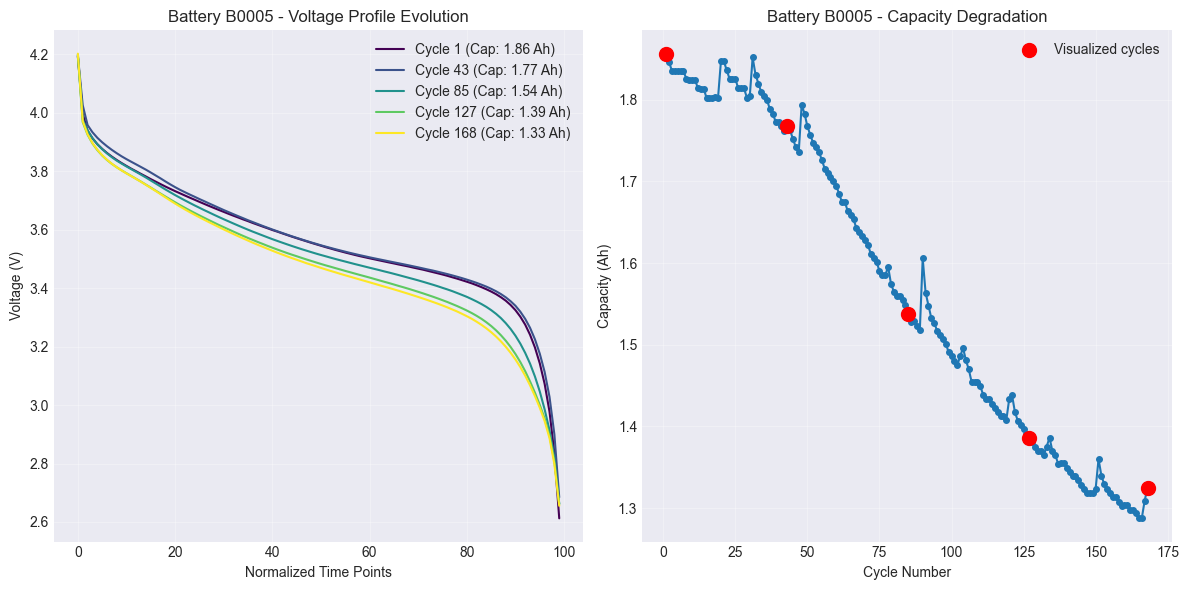

In [28]:
# Select one battery to visualize degradation over time
battery_id = 'B0005'  # This showed good degradation pattern
battery_mask = sequence_dataset['battery_ids'] == battery_id

battery_voltages = sequence_dataset['sequences']['voltage'][battery_mask]
battery_capacities = sequence_dataset['capacities'][battery_mask]
battery_cycles = sequence_dataset['cycle_numbers'][battery_mask]

# Select cycles to visualize (early, middle, late)
n_cycles = len(battery_cycles)
cycle_indices = [0, n_cycles//4, n_cycles//2, 3*n_cycles//4, n_cycles-1]

plt.figure(figsize=(12, 6))

# Voltage profiles
plt.subplot(1, 2, 1)
colors = plt.cm.viridis(np.linspace(0, 1, len(cycle_indices)))
for i, idx in enumerate(cycle_indices):
    plt.plot(battery_voltages[idx], color=colors[i], 
             label=f'Cycle {battery_cycles[idx]} (Cap: {battery_capacities[idx]:.2f} Ah)')
plt.xlabel('Normalized Time Points')
plt.ylabel('Voltage (V)')
plt.title(f'Battery {battery_id} - Voltage Profile Evolution')
plt.legend()
plt.grid(True, alpha=0.3)

# Capacity degradation
plt.subplot(1, 2, 2)
plt.plot(battery_cycles, battery_capacities, 'o-', markersize=4)
plt.scatter(battery_cycles[cycle_indices], battery_capacities[cycle_indices], 
           color='red', s=100, zorder=5, label='Visualized cycles')
plt.xlabel('Cycle Number')
plt.ylabel('Capacity (Ah)')
plt.title(f'Battery {battery_id} - Capacity Degradation')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### **4.5 Save Processed Dataset**

In [29]:
# Save the complete dataset
output_file = os.path.join(BASE_PATH, "sequence_dataset_interpolated.pkl")
with open(output_file, 'wb') as f:
    pickle.dump(sequence_dataset, f)
print(f"Sequence dataset saved to: {output_file}")

# Also save the clean features dataframe
discharge_features_clean.to_csv(
    os.path.join(BASE_PATH, "discharge_features_clean.csv"), 
    index=False
)
print(f"Clean features saved to: {os.path.join(BASE_PATH, 'discharge_features_clean.csv')}")

Sequence dataset saved to: cleaned_dataset/sequence_dataset_interpolated.pkl
Clean features saved to: cleaned_dataset/discharge_features_clean.csv


### **5. Deep Learning Data Preparation**

#### **5.1 Import Deep Learning Libraries**